In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt




In [2]:
!pip uninstall -y patsy
!pip install patsy==0.5.6

Found existing installation: patsy 0.5.6
Uninstalling patsy-0.5.6:
  Successfully uninstalled patsy-0.5.6
  Using cached patsy-0.5.6-py2.py3-none-any.whl.metadata (3.5 kB)
Using cached patsy-0.5.6-py2.py3-none-any.whl (233 kB)


In [3]:
!pip install --upgrade seaborn statsmodels

In [2]:
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load dataset
filepath ='/content/drive/MyDrive/data_file.csv'
data = pd.read_csv(filepath)

# Basic info
print(data.head())
print(data.info())

   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  
0  M1979787155             0.0             0.0        0  
1  M2044282225             0.0             0.0        0  
2   C553264065             0.0             0.0        1  
3    C38997010         21182.0             0.0        1  
4  M1230701703             0.0             0.0        0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51623 entries, 0 to 51622
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0

In [5]:
# Convert categorical 'type' to numeric
data = pd.get_dummies(data, columns=['type'], drop_first=True)

# Features & Target
X = data.drop(['isFraud', 'nameOrig', 'nameDest'], axis=1)
y = data['isFraud']

# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [6]:
# Logistic Regression Model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)

# Train
model.fit(X_train, y_train)

# Predictions (probabilities)
train_probs = model.predict_proba(X_train)[:, 1]
test_probs = model.predict_proba(X_test)[:, 1]

# Convert to binary using threshold
train_preds = (train_probs > 0.5).astype(int)
test_preds = (test_probs > 0.5).astype(int)

In [7]:
# Evaluation
from sklearn.metrics import roc_auc_score, accuracy_score

print("Logistic Regression Results:\n")

print("Training ROC-AUC:", roc_auc_score(y_train, train_probs))
print("Validation ROC-AUC:", roc_auc_score(y_test, test_probs))

print("\nTraining Accuracy:", accuracy_score(y_train, train_preds))
print("Validation Accuracy:", accuracy_score(y_test, test_preds))

Logistic Regression Results:

Training ROC-AUC: 0.9758573567507188
Validation ROC-AUC: 0.9637704599857669

Training Accuracy: 0.9982565862297985
Validation Accuracy: 0.9981920320268612


Decision Tree

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

# Initialize model
dt_model = DecisionTreeClassifier(
    criterion='entropy',   # better for classification
    max_depth=5,           # control overfitting
    random_state=42
)


In [9]:
# Train model
dt_model.fit(X_train, y_train)

# Predictions (probabilities)
train_probs = dt_model.predict_proba(X_train)[:, 1]
test_probs = dt_model.predict_proba(X_test)[:, 1]

# Convert to binary
train_preds = (train_probs > 0.5).astype(int)
test_preds = (test_probs > 0.5).astype(int)


In [10]:
# Evaluation
print("Decision Tree Results:\n")

print("Training ROC-AUC:", roc_auc_score(y_train, train_probs))
print("Validation ROC-AUC:", roc_auc_score(y_test, test_probs))

print("\nTraining Accuracy:", accuracy_score(y_train, train_preds))
print("Validation Accuracy:", accuracy_score(y_test, test_preds))

Decision Tree Results:

Training ROC-AUC: 0.9799934247530322
Validation ROC-AUC: 0.8768702421772228

Training Accuracy: 0.9982012397609032
Validation Accuracy: 0.9980628914573513


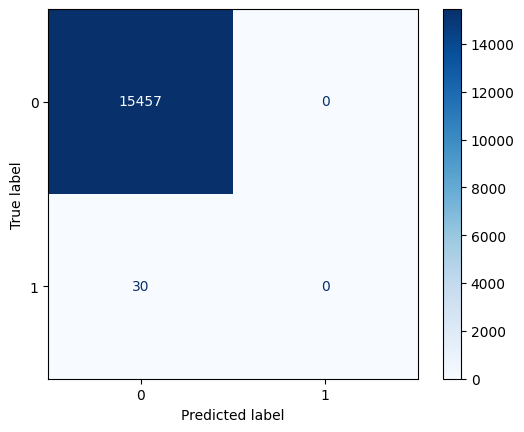

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, test_preds, cmap='Blues')
plt.show()

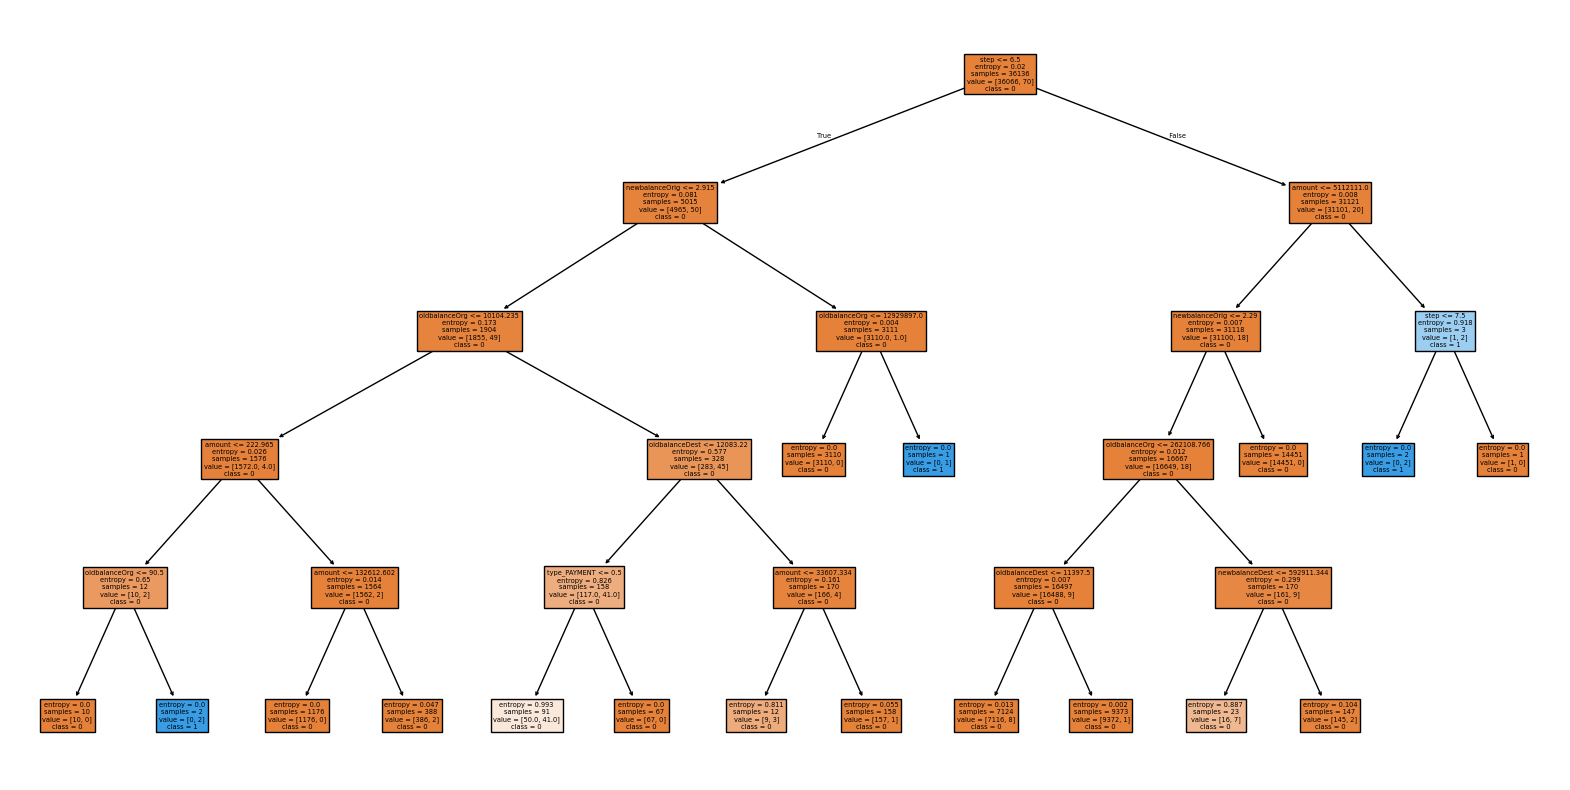

In [12]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(dt_model, filled=True, feature_names=X.columns, class_names=['0','1'])
plt.show()

Random Forest

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=100,        # number of trees
    max_depth=7,             # control overfitting
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1                # use all CPU cores
)
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',   # 🔥 important for fraud data
    random_state=42,
    n_jobs=-1
)

In [14]:
# Train model
rf_model.fit(X_train, y_train)

# Predictions (probabilities)
train_probs = rf_model.predict_proba(X_train)[:, 1]
test_probs = rf_model.predict_proba(X_test)[:, 1]

# Convert to binary
train_preds = (train_probs > 0.5).astype(int)
test_preds = (test_probs > 0.5).astype(int)

In [15]:
# Evaluation
print("Random Forest Results:\n")

print("Training ROC-AUC:", roc_auc_score(y_train, train_probs))
print("Validation ROC-AUC:", roc_auc_score(y_test, test_probs))

print("\nTraining Accuracy:", accuracy_score(y_train, train_preds))
print("Validation Accuracy:", accuracy_score(y_test, test_preds))

Random Forest Results:

Training ROC-AUC: 0.9999821755353281
Validation ROC-AUC: 0.9768950421599707

Training Accuracy: 0.9997786141244188
Validation Accuracy: 0.998644024020146


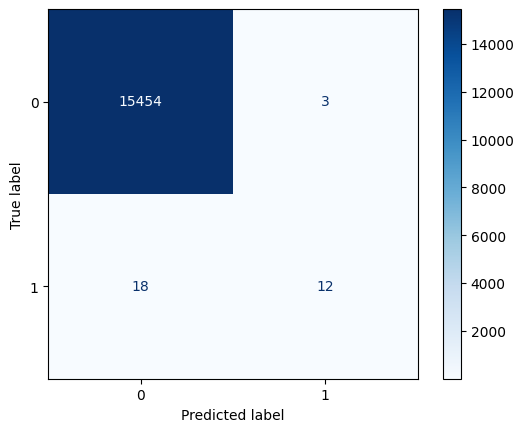

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, test_preds, cmap='Blues')
plt.show()

Feature Importance (Very Useful Insight)

In [17]:
import pandas as pd

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(10))

step              0.202105
oldbalanceDest    0.165966
type_PAYMENT      0.151883
newbalanceOrig    0.135179
oldbalanceOrg     0.117660
amount            0.084302
newbalanceDest    0.057616
type_TRANSFER     0.045364
type_CASH_OUT     0.038681
type_DEBIT        0.001245
dtype: float64


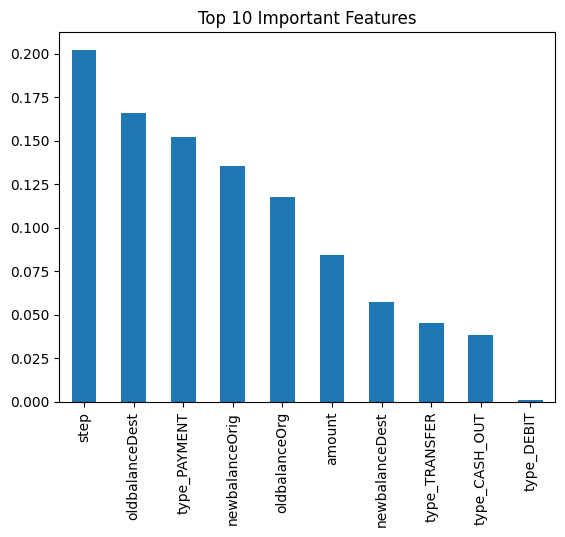

In [18]:
# Plot
feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()